# Improving AI Chatbot Response Accuracy with LangChain Tooling

Large Language Models (LLMs) are the AI models that powers modern chatbots like ChatGPT and Claude.

Despite the powerful capabilities of these models, standalone LLMs struggle to solve a slew of tasks that are easily and quickly solved with a traditional programmatic approach. Although one could leverage conventional deterministic tools to solve these kinds of problems, users tend to prefer the convenience and ease of use that comes with prompting chatbots using natural language.

This notebook will demonstrate that by providing LLMs with an agentic workflow and appropriate tooling, response speed and accuracy can be significantly improved for specific tasks. This technique could then be applied as part of a chatbot system to provide users with more accurate responses.

---

**PLEASE NOTE:** I highly recommend switching to a T4 GPU runtime if you plan on running the code yourself inside of Colab. This will significantly increase the inference speed for the LLM. You can do so by clicking `Runtime` -> `Change runtime type` in the menu bar above.

---

## Install Ollama
Let's begin by installing Ollama. This tool allows us to download and run LLMs, and supports integration with Python:

In [ ]:
!sudo apt-get install zstd pciutils
!curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpci3 pci.ids
The following NEW packages will be installed:
  libpci3 pci.ids pciutils zstd
0 upgraded, 4 newly installed, 0 to remove and 2 not upgraded.
Need to get 946 kB of archives.
After this operation, 3,276 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 pci.ids all 0.0~2022.01.22-1ubuntu0.1 [251 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpci3 amd64 1:3.7.0-6 [28.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 pciutils amd64 1:3.7.0-6 [63.6 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 946 kB in 1s (734 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debc

## Start the Ollama server

Once Ollama is installed in our environment, we can start the Ollama server that will host our LLM:

In [ ]:
import time
import subprocess

def start_ollama_server():
  # check if ollama server is already running
  try:
    subprocess.check_output(['curl', 'http://localhost:11434'])

  # if not already running
  except Exception:
    # start ollama server
    subprocess.Popen(['ollama', 'serve'])

    # give it time to initialize
    time.sleep(10)

  # print version
  print(subprocess.check_output(['ollama', '--version']).decode("utf-8"))


start_ollama_server()

ollama version is 0.21.0



## Download our model

The model I'll be using in this notebook is Qwen 3.5, specifically the 9 billion parameter variant. This is an open-weight model created by Alibaba Cloud and released in February 2026. This version of the model is also 4-bit quantized, with makes for a relatively small memory footprint (around 6.6 GB).

One main reason I opted to use Ollama is because I can't afford to pay an inference provider to run a fancier model. On top of that, I already have some Colab credits laying around that I don't mind burning through.


Although this model is **much smaller** than frontier models like ChatGPT or Claude, it's still very capable for it's size, and will work well for this demonstration.

Let's download our model:

In [ ]:
# download our model
!ollama pull qwen3.5:9b

# show our installed models
!ollama list


NAME          ID              SIZE      MODIFIED               
qwen3.5:9b    6488c96fa5fa    6.6 GB    Less than a second ago    


After running the above code block, we should be able to see that `qwen3.5:9b` is installed and registered by Ollama.

## Import libraries

To interact with Ollama models using Python, we'll need the `ollama` Python library. We'll also need the `langchain` library and `langchain-ollama` to create a LangChain agent using our Ollama model.

LangChain is a library for creating AI agents using Python or JavaScript. We'll be using it to turn our Ollama model into a simple agent with tooling. I will also import a library to measure response time, as well as some IPython functions to render markdown in the model's response.

Let's make sure LangChain and it's Ollama integration library is installed and up to date. Then, we'll import the objects, functions and decorators we'll need:


In [ ]:
# @title Import libraries
# install/update langchain, ollama
!pip install -U langchain langchain-ollama ollama

# langchain agent imports
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_core.messages import AIMessage, ToolMessage, SystemMessage, HumanMessage

# ollama library for python
import ollama

# ollama wrapper for langchain
from langchain_ollama import ChatOllama

# imports for timer
import time
from contextlib import contextmanager

# imports to display markdown in jupyter notebook
from IPython.display import Markdown, display

# import pandas, seaborn, matplotlib for analyzing results
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## Demonstrating standalone model performance



Instead of simply evaluating whether our model gives a correct response, we can also measure the time it takes for the model to respond. This can be a valuable metric to understand the performance of an LLM, since compute is not free. The less time it takes to get our response, the better (and cheaper).

Let's set up a timer so that we can see how long our responses take to generate:

In [ ]:
# timer class to yield in our timer function
class Timer:
  def __init__(self):
      self.elapsed = 0.0 # where final runtime is stored

# timer function wrapped as context manager
@contextmanager
def time_it():
  t = Timer()
  start = time.perf_counter()
  yield t
  t.elapsed = time.perf_counter() - start

We'll also create some functions to make the presentation a bit tidier.

`run_inference()` will run a single trial for a given task, and print the results.

`ansi_color()` will apply red or green ANSI colors to a string based on a given condition. This just makes the results look prettier.

`check_response` will take the model's response along with the correct answer to the problem. The function will then strip any whitespace and return the response with ANSI colors applied. The response will show up green if it matches the provided correct answer, and red if it doesn't match.

In [ ]:
def run_inference(
    prompt: str,                # the prompt we want to send to the model
    model: str = "qwen3.5:9b",  # model to use
    temperature: float = 0.5 ,  # temperature for model
    think: bool = False,        # reasoning mode (off by default)
    num_predict: int = 4096     # token limit for reasoning + response
) -> tuple[Timer, dict]:
  """Wrapper function for running inference using Ollama/Qwen. Returns Timer and Ollama response"""

  # format our prompt as a user message
  messages = [{"role": "user", "content": prompt}]

  # start timer
  with time_it() as t:
    # query our model
    response = ollama.chat(
        model=model,
        messages=messages,
        think=think,
        options={
            'num_predict': num_predict,
            'temperature': temperature
            }
    )

  # if model failed to respond
  if not response['message']['content']:

    # populate response content to indicate that
    response['message']['content'] = "<model failed to respond>"

  return (t, response)


def ansi_color(string: str, cond: bool) -> str:
  """Apply ansi codes to a string based on expression (cond)."""
  # ansi color codes
  f_red = "\033[31m"
  f_green = "\033[32m"
  f_reset = "\033[0m"

  # make sure string is actually a string
  string = str(string)

  # set to green if cond true, else red
  f_color = f_green if cond else f_red
  return f_color + string + f_reset


def check_response(response, ans):
  """Signify correct/incorrect response with ansi colors."""
  # remove whitespace from response
  response = str(response).strip()

  # set color based on expression (response == answer)
  return ansi_color(response, (response == str(ans)))

## Preliminary Tests

Let's test our model by asking it to solve a relatively simple arithmetic problem. This will serve as a preliminary test to help us understand it's capabilities.

I'll be running the model twice to demonstrate the reasoning (AKA thinking) mode on. This feature encourages the model to work through a given problem in multiple steps using natural language. The model then provides a final response, omitting the reasoning steps it used to solve the problem.

The main tradeoff with reasoning mode is that the model will often take longer and use more compute to provide a response. The actual discrepancy between reasoning and non-reasoning compute will vary depending on the complexity of the task.

Let's see it in action:

In [ ]:
# make a list of numbers to sum
numbers = [1, 5, 6, 3, 7, 72]

# start ollama server if not already running
start_ollama_server()

# initial inference call to load model into memory
print("Initializing model...")
t, response = run_inference("Ready?")
print(f"Model loaded in {t.elapsed:.4f} seconds.")

# construct our prompt
prompt = f"What is the sum of the numbers {numbers}? Respond with the answer only."
print(f"Prompt: {prompt}\n")

# calculate and print real answer
with time_it() as t:
  ans = sum(numbers)
print(f"\tReal answer:\n\t{ansi_color(ans, True)}\n\t({t.elapsed:.4f} seconds)\n")

# run inference and get model's answer
t, response = run_inference(prompt)
res = response['message']['content'] # isolate response content
print(f"\tQwen's answer (reasoning off):\n\t{check_response(res,ans)}\n\t({t.elapsed:.4f} seconds)\n")

# run again with reasoning turned on
t, response = run_inference(prompt, think=True)
res = response['message']['content']
print(f"\tQwen's answer (reasoning on):\n\t{check_response(res,ans)}\n\t({t.elapsed:.4f} seconds)")

ollama version is 0.21.0

Initializing model...
Model loaded in 145.3667 seconds.
Prompt: What is the sum of the numbers [1, 5, 6, 3, 7, 72]? Respond with the answer only.

	Real answer:
	94
	(0.0000 seconds)

	Qwen's answer (reasoning off):
	91
	(0.4917 seconds)

	Qwen's answer (reasoning on):
	94
	(13.0583 seconds)


In the results, you should see 3 separate tests:
1. The answer to the problem **calculated programmatically**, which happens virtually instantaneously.
2. Our model's response with **reasoning mode turned off**, which happens in less than a second.
3. Our model's response with **reasoning mode turned on**, which takes around 15 seconds.

We can see that reasoning does make much longer and uses more tokens to solve this task. With that being said, the model was only able to produce the correct answer with reasoning mode turned on.

Let's take a peek at the model's reasoning process to get an idea of how it worked through this problem:

In [ ]:
# @title Show reasoning process
display(Markdown(response['message']['thinking']))

Thinking Process:

1.  **Analyze the Request:** The user wants the sum of the numbers in the list [1, 5, 6, 3, 7, 72]. The response should contain only the answer.

2.  **Perform the Calculation:**
    *   List: 1, 5, 6, 3, 7, 72
    *   Sum: 1 + 5 + 6 + 3 + 7 + 72
    *   Step-by-step:
        *   1 + 5 = 6
        *   6 + 6 = 12
        *   12 + 3 = 15
        *   15 + 7 = 22
        *   22 + 72 = 94

3.  **Verify the Calculation:**
    *   Group small numbers: (1 + 5 + 6 + 3 + 7) = 22
    *   Add the large number: 22 + 72 = 94
    *   Alternative grouping: (1 + 6 + 3 + 7) + (5 + 72) = 17 + 77 = 94.
    *   Alternative grouping: (1 + 5) + (6 + 3) + (7 + 72) = 6 + 9 + 79 = 15 + 79 = 94.

4.  **Format the Output:** The user requested "Respond with the answer only."

5.  **Final Answer:** 94.

Here we can see exactly what the model generated to assist itself in working through this problem.

Because LLMs continue a sequence of text by probabilistically predicting the next token, the model isn't actually peforming arithmetic to produce these answers.
Nevertheless, it's interesting how modelling a human approach can assist the model in finding the correct answer. It appears the model employed a few different approaches in order to verify it's answer.



## Running Multiple Trials

Although the previous example makes for a pretty solid demonstration, we can get a better understanding of the model's performance at scale by conducting multiple trials and tracking the results.

Let's write a function to simplify the process of running multiple trials for our experiments:



In [ ]:
def run_experiment(
    n: int,                   # number of trials
    prompt: str,              # prompt in
    ans,                      # correct answer for problem
    category: str,            # experiment category for DataFrame
    model="qwen3.5:9b",       # model to use
    temperature: float = 0.5, # model temperature
    num_predict: int = 4096   # token limit for generation
) -> pd.DataFrame:
  """Runs n trials for a given prompt, both with reasoning disabled and enabled. Returns dataframe of results. """

  # results list contains 2 dictionaries
  # one for non-reasoning trials, another for reasoning trials
  results = [{
      'success': [0] * n,
      'token_count': [0] * n,
      'time': [0.0] * n,
      'content': [""] * n,
      'reasoning': [""] * n,
      'model': [model] * n,
      'category': [category] * n
  } for i in range(2)]

  # add extra kvs to dictionary for dataframe
  results[0]['group'] = ["reasoning_off"] * n
  results[1]['group'] = ["reasoning_on"] * n

  # for each experiment
  for i in range(2):
    # think = False for first experiment, True for second
    think = bool(i)
    header = "on" if think else "off"
    print(f"\n\tQwen's answers (reasoning {header}):")

    # for each trial in experiment
    for j in range(n):
      t, response = run_inference(
          prompt=prompt,
          model=model,
          temperature=temperature,
          think=think,
          num_predict=num_predict
      )

      # print results for each trial
      res = response['message']['content']
      token_count = response['eval_count']
      print(f"\t{check_response(res,ans)}\t({t.elapsed:.4f} seconds)\t({token_count} tokens)")

      # populate results for each trial in experiment
      results[i]['success'][j] = 1 if res == str(ans) else 0
      results[i]['token_count'][j] = token_count
      results[i]['time'][j] = t.elapsed
      results[i]['content'][j] = res
      if think:
        results[i]['reasoning'][j] = response['message']['thinking']

  # summary metrics
  print("\n\n" + "-"*20 + "\nFinal Results:\n")
  print(f"\tQwen (reasoning off):")
  print(f"\tScore: {sum(results[0]['success'])}/{n}")
  print(f"\tAverage Time: {sum(results[0]['time'])/n:.4f} seconds")
  print(f"\tAverage Tokens Used: {sum(results[0]['token_count'])/n}")

  print(f"\n\tQwen (reasoning on):")
  print(f"\tScore: {sum(results[1]['success'])}/{n}")
  print(f"\tAverage Time: {sum(results[1]['time'])/n:.4f} seconds")
  print(f"\tAverage Tokens Used: {sum(results[1]['token_count'])/n}")

  # return results
  return pd.concat([pd.DataFrame(results[0]), pd.DataFrame(results[1])], ignore_index=True)

This function will take our prompt, and run `n` trials for each of our two experiments: Our model with reasoning off, and and again with reasoning turned on. The function will also automatically print the results of each trial for both experiments, and some final metrics about the overall results for each experiment. It will then return a pandas DataFrame object containing the results for each trial.

Here's how we can use this function to run experiments for a task:

In [ ]:
# make a list of numbers to sum
numbers = [1, 5, 6, 3, 7, 72]

# number of trials
n = 10

# start ollama server if not already running
start_ollama_server()

# initial inference call to load model into memory
print("Initializing model...")
t, response = run_inference("Ready?")
print(f"Model loaded in {t.elapsed:.4f} seconds.")

# construct our prompt
prompt = f"What is the sum of the numbers {numbers}? Respond with the answer only."
print(f"Prompt: {prompt}\n")

# calculate and print real answer
with time_it() as t:
  ans = sum(numbers)
print(f"\tReal answer:\n\t{ansi_color(ans, True)}\n\t({t.elapsed:.4f} seconds)")

# run experiment
results = run_experiment(n, prompt, ans, "sum_list")

ollama version is 0.21.0

Initializing model...
Model loaded in 0.9687 seconds.
Prompt: What is the sum of the numbers [1, 5, 6, 3, 7, 72]? Respond with the answer only.

	Real answer:
	94
	(0.0000 seconds)

	Qwen's answers (reasoning off):
	101	(0.4973 seconds)	(4 tokens)
	91	(0.4475 seconds)	(3 tokens)
	101	(0.5055 seconds)	(4 tokens)
	91	(0.4697 seconds)	(3 tokens)
	91	(0.4226 seconds)	(3 tokens)
	91	(0.4518 seconds)	(3 tokens)
	91	(0.4478 seconds)	(3 tokens)
	91	(0.4421 seconds)	(3 tokens)
	91	(0.4663 seconds)	(3 tokens)
	91	(0.4564 seconds)	(3 tokens)

	Qwen's answers (reasoning on):
	94	(13.2696 seconds)	(328 tokens)
	94	(12.7612 seconds)	(339 tokens)
	94	(23.7179 seconds)	(621 tokens)
	94	(14.1326 seconds)	(344 tokens)
	94	(14.0176 seconds)	(338 tokens)
	94	(24.7659 seconds)	(603 tokens)
	94	(13.1663 seconds)	(317 tokens)
	94	(16.3550 seconds)	(392 tokens)
	94	(17.8988 seconds)	(429 tokens)
	94	(16.0638 seconds)	(387 tokens)


--------------------
Final Results:

	Qwen (reasonin

From these results, we can see more clearly that reasoning mode makes a big difference for complex problems. The model failed every trial when reasoning was turned off, and succeeded every trial when it was turned on.

We can also see how reasoning usually takes longer to complete, and uses far more tokens. Two factors that affect inference time are the model's size, as well as the hardware the model is running on. Despite the fact that I'm using a T4 GPU runtime for this notebook, it's still very slow compared to the kind of compute you'd see in a modern datacenter running frontier models.

Let's take a look at our `results` DataFrame to see what we've stored inside:

In [ ]:
results

,success,token_count,time,content,reasoning,model,category,group
0,0,4,0.497264,101,,qwen3.5:9b,sum_list,reasoning_off
1,0,3,0.447502,91,,qwen3.5:9b,sum_list,reasoning_off
2,0,4,0.505550,101,,qwen3.5:9b,sum_list,reasoning_off
3,0,3,0.469663,91,,qwen3.5:9b,sum_list,reasoning_off
4,0,3,0.422605,91,,qwen3.5:9b,sum_list,reasoning_off
5,0,3,0.451823,91,,qwen3.5:9b,sum_list,reasoning_off
6,0,3,0.447799,91,,qwen3.5:9b,sum_list,reasoning_off
7,0,3,0.442146,91,,qwen3.5:9b,sum_list,reasoning_off
8,0,3,0.466306,91,,qwen3.5:9b,sum_list,reasoning_off
9,0,3,0.456428,91,,qwen3.5:9b,sum_list,reasoning_off


The DataFrame includes the inference time and token usage for each trial, along with other metadata including the reasoning process, task category, experiment group and success/fail for each trial.

I'm going to create an empty Pandas DataFrame called `df` to store the results of the next experiments. That way, we can append our results to this dataframe after each run, and perform a final analysis at the end to compare the results:

In [ ]:
df = pd.DataFrame()

---

## Multiplying large numbers
Now it's time to up the ante. We've just witnessed one problem that standalone LLMs struggle with: solving complex arithmetic. This is especially true when asking them to multiply two large numbers.

Let's see how capable our Qwen model is at multiplying two 7-digit numbers:

In [ ]:
# choose two numbers to mulitply
a = 1184758
b = 8375948

# number of trials
n = 10

# start ollama server if not already running
start_ollama_server()

# initial inference call to load model into memory
print("Initializing model...")
t, response = run_inference("Ready?")
print(f"Model loaded in {t.elapsed:.4f} seconds.")

# construct our prompt
prompt = f"What is {a} multiplied by {b}? Respond with the answer only."
print(f"Prompt: {prompt}\n")

# calculate and print real answer
with time_it() as t:
  ans = a * b
print(f"\tReal answer:\n\t{ansi_color(ans, True)}\n\t({t.elapsed:.4f} seconds)\n")

# run experiment
results = run_experiment(n, prompt, ans, "large_mul")

# append to df to store final results
df = pd.concat([df, results], ignore_index=True)

ollama version is 0.21.0

Initializing model...
Model loaded in 0.9716 seconds.
Prompt: What is 1184758 multiplied by 8375948? Respond with the answer only.

	Real answer:
	9923471400584
	(0.0000 seconds)


	Qwen's answers (reasoning off):
	972338479938	(0.9067 seconds)	(13 tokens)
	9723380939572	(0.9087 seconds)	(14 tokens)
	972339862512	(1.1352 seconds)	(13 tokens)
	972339577718	(1.1730 seconds)	(13 tokens)
	972342602438	(1.0853 seconds)	(13 tokens)
	9723425344726	(0.9289 seconds)	(14 tokens)
	9723390362386	(0.9483 seconds)	(14 tokens)
	9723440061176	(0.9074 seconds)	(14 tokens)
	972344757458	(0.8926 seconds)	(13 tokens)
	9723376987572	(0.9089 seconds)	(14 tokens)

	Qwen's answers (reasoning on):
	<model failed to respond>	(169.7741 seconds)	(4096 tokens)
	<model failed to respond>	(170.0313 seconds)	(4096 tokens)
	<model failed to respond>	(169.8929 seconds)	(4096 tokens)
	<model failed to respond>	(170.6285 seconds)	(4096 tokens)
	<model failed to respond>	(170.1014 seconds)	(4096 

As you can see, the model does not perform well with this kind of problem. I've tested this multiple times, and I have yet to see it answer this problem correctly without agentic tooling.

### Why does the model suck at this?

Let's take a look at the reasoning process for the last trial and see what went wrong:

In [ ]:
# @title Show reasoning for final trial
# show reasoning for experiment 2, trial 10
display(Markdown(results.iloc[19]['reasoning']))

Thinking Process:

1.  **Analyze the Request:** The user wants the product of two numbers: 1,184,758 and 8,375,948. The constraint is to respond with the answer only.

2.  **Perform the Multiplication:**
    *   Number A: 1,184,758
    *   Number B: 8,375,948
    *   Calculation: $1184758 \times 8375948$

    Let's break it down or use a simulated calculator approach.
    $1184758 \times 8375948$

    Approximation check:
    $1.18 \times 10^6 \times 8.37 \times 10^6 \approx 9.8 \times 10^{12}$
    So the answer should be around 9.9 trillion.

    Let's compute precisely:
    $1184758 \times 8375948$

    Using column multiplication logic (or mental simulation):
    $1184758 \times 8 = 9478064$
    $1184758 \times 40 = 47390320$
    $1184758 \times 900 = 1066282200$
    $1184758 \times 5000 = 5923790000$
    $1184758 \times 70000 = 82933060000$
    $1184758 \times 300000 = 355427400000$
    $1184758 \times 8000000 = 9478064000000$

    Summing them up:
    Start with the smallest:
    $9,478,064$
    $+ 47,390,320$
    $= 56,868,384$

    $+ 1,066,282,200$
    $= 1,123,150,584$

    $+ 5,923,790,000$
    $= 7,046,940,584$

    $+ 82,933,060,000$
    $= 89,979,000,584$ (Wait, let's re-add carefully)
    $7,046,940,584 + 82,933,060,000 = 89,979,000,584$?
    $7+82 = 89$
    $046+933 = 979$
    $940+060 = 1000$ (Wait, borrowing?)
    Let's write it vertically.

          1 1 8 4 7 5 8
        x 8 3 7 5 9 4 8
        -----------------

    This is prone to error without a tool. I will simulate the arithmetic carefully.

    $1184758 \times 8375948$

    Let $x = 1184758$
    $y = 8375948$

    $x \times 8 = 9478064$
    $x \times 40 = 47390320$
    $x \times 900 = 1066282200$
    $x \times 5000 = 5923790000$
    $x \times 70000 = 82933060000$
    $x \times 300000 = 355427400000$
    $x \times 8000000 = 9478064000000$

    Summing:
      0000009478064
      0000047390320
      0001066282200
      005923790000
      082933060000
      355427400000
    9478064000000

    Let's align by magnitude (units):
       9478064
      47390320
     1066282200
      5923790000
     82933060000
    355427400000
    9478064000000

    Sum:
    Units: 4+0 = 4
    Tens: 6+2 = 8
    Hundreds: 0+3+2 = 5
    Thousands: 8+0+2+0+0+0 = 10 (0 carry 1) -> Wait, 8+0+2+0+0+0 = 10.
    Let's list digits from right to left (indices 0 to 12).

    Index 0 (1s): 4+0+0+0+0+0+0 = 4
    Index 1 (10s): 6+2+0+0+0+0+0 = 8
    Index 2 (100s): 0+3+2+0+0+0+0 = 5
    Index 3 (1k): 8+0+2+0+0+0+0 = 10 -> 0 carry 1
    Index 4 (10k): 7+9+8+9+0+4+0 + 1(carry) = 38 -> 8 carry 3
       Wait, let's look at the terms again.
       Term 1: 9,478,064
       Term 2: 47,390,320
       Term 3: 1,066,282,200
       Term 4: 5,923,790,000
       Term 5: 82,933,060,000
       Term 6: 355,427,400,000
       Term 7: 9,478,064,000,000

       Let's sum column by column.

       Column 0 (1s):
       4
       Sum = 4. Result ends in 4.

       Column 1 (10s):
       6, 2, 0, 0, 0, 0, 0
       Sum = 8. Result ends in 84.

       Column 2 (100s):
       0, 3, 2, 0, 0, 0, 0
       Sum = 5. Result ends in 584.

       Column 3 (1k):
       8, 0, 2, 0, 0, 0, 0
       Sum = 10. Result digit 0, carry 1.
       Result ends in 0584.

       Column 4 (10k):
       7, 9, 8, 9, 0, 4, 0
       Sum = 7+9+8+9+4 = 37
       + 1 carry = 38.
       Digit 8, carry 3.
       Result ends in 80584.

       Column 5 (100k):
       4, 3, 6, 7, 6, 7, 6
       Wait, let's extract digits properly.
       Term 1: ...064
       Term 2: ...320
       Term 3: ...2200
       Term 4: ...90000
       Term 5: ...060000
       Term 6: ...400000
       Term 7: ...4000000

       Let's write the full numbers aligned:
         0000000009478064
         000000047390320
         0001066282200
         00005923790000
         00082933060000
         0355427400000
         9478064000000

       Summing from right:
       Pos 0: 4
       Pos 1: 6+2=8
       Pos 2: 0+3+2=5
       Pos 3: 8+0+2=10 -> 0, c1
       Pos 4: 7+9+8+9+0+4+0 +1(carry) = 38 -> 8, c3
       Pos 5: 4+3+6+7+6+7+6 +3(carry) = 42?
         Let's check digits at pos 5 (100,000s).
         Term 1: 4
         Term 2: 3
         Term 3: 6
         Term 4: 7
         Term 5: 3
         Term 6: 4
         Term 7: 0
         Sum: 4+3+6+7+3+4+0 = 27. +3 carry = 30. -> 0, c3.
       Pos 6 (1,000,000s):
         Term 1: 0
         Term 2: 0
         Term 3: 0
         Term 4: 2
         Term 5: 9
         Term 6: 2
         Term 7: 6
         Sum: 2+9+2+6 = 19. +3 carry = 22 -> 2, c2.
       Pos 7 (10,000,000s):
         Term 1: 9
         Term 2: 4
         Term 3: 6
         Term 4: 9
         Term 5: 2
         Term 6: 4
         Term 7: 8
         Sum: 9+4+6+9+2+4+8 = 42. +2 carry = 44 -> 4, c4.
       Pos 8 (100,000,000s):
         Term 1: 0
         Term 2: 0
         Term 3: 1
         Term 4: 0
         Term 5: 8
         Term 6: 5
         Term 7: 4
         Sum: 1+8+5+4 = 18. +4 carry = 22 -> 2, c2.
       Pos 9 (1,000,000,000s):
         Term 1: 0
         Term 2: 0
         Term 3: 0
         Term 4: 5
         Term 5: 8? Wait, Term 5 is 82,933,060,000. Digits: 082933060000.
         Let's rewrite numbers to align properly.

       1. 000,000,094,780,64
       2. 000,000,473,903,20
       3. 001,066,282,200
       4. 005,923,790,000
       5. 082,933,060,000
       6. 355,427,400,000
       7. 9,478,064,000,000

       Let's sum carefully.
       Units: 4
       Tens: 6+2 = 8
       Hundreds: 0+3+2 = 5
       Thousands: 8+0+2 = 10 -> 0, c1
       Ten Thousands: 7+9+8+9+4+0 +1 = 38 -> 8, c3
       Hundred Thousands: 4+3+6+7+3+4+0 +3 = 30 -> 0, c3
       Millions: 9+0+6+2+9+2+6 +3 = 37 -> 7, c3
       Ten Millions: 0+4+0+0+3+5+8 +3 = 23 -> 3, c2
       Hundred Millions: 0+0+1+0+8+5+4 +2 = 20 -> 0, c2
       Billions: 0+0+0+5+2+5+7 +2 = 21 -> 1, c2
       Trillions: 0+0+0+0+0+3+9 +2 = 14 -> 4, c1
       Quadrillions: 0+0+0+0+0+0+0 +1 = 1
       Wait, I need to check the digits again. It's easy to miss a digit.

       Let's use a different method to ensure accuracy.
       $1184758 \times 8375948$
       $(1184758) \times (8375948)$

       Use modular arithmetic or splitting.
       Or simply trust the calculation logic if I can do it step by step without error.
       Let's try Python-like mental execution.
       $1184758 \times 8375948$
       $= 1184758 \times (8375000 + 948)$
       $= 1184758 \times 8375000 + 1184758 \times 948$

       $1184758 \times 8375000 = 1184758 \times 8375 \times 1000$
       $1184758 \times 8375$:
       $1184758 \times (8000 + 300 + 70 + 5)$
       $= 9478064000$
       $+ 355427400$
       $+ 82933060$
       $+ 5923790$
       Sum:
       9478064000
         355427400
           82933060
            5923790
       Summing:
       000: 000+000+060+790 = 750
       0000: 00+40+7000+000 = 4000+7000?
       Let's align:
         9478064000
          355427400
           82933060
            5923790
       -----------------
       Last 3: 000+400+060+790 = 1250. (Wait 400+60+790 = 1250)
       Next 3: 064+427+933+923 = 2347. +1 (carry) = 2348.
       Next 3: 9478+355+82+59 = ?
       Let's re-align properly.
       9,478,064,000
       355,427,400
       82,933,060
       5,923,790
       -------------
       000
       000+400+060+790 = 1250 -> 250 carry 1
       064+427+933+923 +1
       64+427=491
       491+933=1424
       1424+923=2347
       2347+1=2348 -> 348 carry 2
       9478+355+82+59 +2
       78+355=433
       433+82=515
       515+59=574
       574+2=576
       Plus the 9478 from term 1?
       Wait, Term 1 is 9,478,064,000.
       So 9478 + 2 = 9480?
       Wait, 574+59 = 633?
       Let's restart the column addition carefully.

       Term 1:  9,478,064,000
       Term 2:    355,427,400
       Term 3:     82,933,060
       Term 4:      5,923,790

       Pos 0-2 (Units): 000 + 400 + 060 + 790 = 1250.
       Result: 250, carry 1 to Pos 3.

       Pos 3-5 (Thousands): 064 + 427 + 933 + 923 + 1(carry)
       64+427 = 491
       491+933 = 1424
       1424+923 = 2347
       2347+1 = 2348.
       Result: 348, carry 2 to Pos 6.

       Pos 6-8 (Millions):
       Term 1: 9478? No, Term 1 is 9,478,064,000.
       The millions part is 9478. Wait, 9 billion.
       9,478,064,000 -> Millions part is 9478.
       Let's look at the digits.
       9 4 7 8 | 0 6 4 | 0 0 0
       0 3 5 5 | 4 2 7 | 4 0 0
       0 0 8 2 | 9 3 3 | 0 6 0
       0 0 0 5 | 9 2 3 | 7 9 0

       Sum columns from right (0):
       Col 0 (Units): 0
       Col 1: 0
       Col 2: 0
       Sum 0-2: 0+400+060+790 = 1250. -> 250, c1.

       Col 3 (Thousands): 4 + 2 + 3 + 2 + 1(carry) ?
       Let's list digits at col 3.
       T1: 4 (from 064) -> 064 is 0,6,4. Col 2 is 4? No.
       Let's align digits by power of 10.
       10^0: 0+0+0+0 = 0
       10^1: 0+0+0+0 = 0
       10^2: 0+0+6+9 = 15? No.
       T1: ...000. Last digits 0,0,0.
       T2: ...400. Last digits 4,0,0.
       T3: ...060. Last digits 0,6,0.
       T4: ...790. Last digits 7,9,0.
       Sum 10^0: 0
       Sum 10^1: 0
       Sum 10^2: 0+4+6+9 = 19. -> 9, c1.
       Wait, my previous calculation was 000+400+060+790 = 1250.
       064 was thousands group? No.
       Let's look at T1: 9,478,064,000.
       Last 3: 000.
       Next 3: 064.
       Next 3: 478.
       Next: 9.

       T2: 355,427,400.
       Last 3: 400.
       Next 3: 427.
       Next 3: 355.

       T3: 82,933,060.
       Last 3: 060.
       Next 3: 933.
       Next 3: 082.

       T4: 5,923,790.
       Last 3: 790.
       Next 3: 923.
       Next 3: 005.

       Now align properly.
       00009478064000
       00000355427400
       00000082933060
       00000005923790
       Sum:
       Group 1 (Units-999): 000 + 400 + 060 + 790.
       000+400=400.
       400+060=460.
       460+790=1250.
       Last 3 digits: 250. Carry 1 to next group.

       Group 2 (Thousands-999 Thousands): 064 + 427 + 933 + 923 + 1(carry).
       64 + 427 = 491.
       491 + 933 = 1424.
       1424 + 923 = 2347.
       2347 + 1 = 2348.
       Last 3 digits: 348. Carry 2 to next group.

       Group 3 (Millions-999 Millions): 478 + 355 + 082 + 005 + 2(carry).
       478 + 355 = 833.
       833 + 82 = 915.
       915 + 5 = 920.
       920 + 2 = 922.
       Result: 922. No carry (or carry 0 since 922 < 1000). Wait, is 922 correct?
       Let's check terms again.
       T1 Millions: 9478?
       T1 is 9,478,064,000. So it's 9 billion, 478 million.
       T2 is 355 million.
       T3 is 82 million.
       T4 is 5 million.

       So Group 3 sum:
       T1: 478
       T2: 355
       T3: 082
       T4: 005
       Carry: 2
       Sum: 478 + 355 + 82 + 5 + 2 = ?
       478 + 355 = 833.
       833 + 82 = 915.
       915 + 5 = 920.
       920 + 2 = 922.
       So millions part is 922.

       Group 4 (Billions):
       T1: 9
       T2: 0
       T3: 0
       T4: 0
       Carry from Group 3: 0.
       Sum: 9.

       So result is 9,922,348,250.

       Let's double check with the original calculation.
       $1184758 \times 838210 \approx 991222977571581 \approx 9.9 \times 10^{14}$.
       Wait, I calculated 9,912,229,775,71,581?
       Let's recount the digits of my manual sum result: 922 million, 348 thousand, 250.
       That is $9,922,348,250$. That is $10^{10}$ magnitude.
       But the multiplication result is $10^{15}$ magnitude.
       Why the difference?
       T1 is 9,478,064,000 (approx 10^10).
       T2 is 355,427,400 (approx 3.5 \times 10^8).
       T3 is 82,933,060 (approx 8 \times 10^7).
       T4 is 5,923,790 (approx 6 \times 10^6).
       These are terms from expansion of $(10^6+4758) \times 10^3 \times (83821) \times 10^4$? No.
       Let's look at the original problem context from previous messages.
       User asked to multiply $1184758 \times 838210$.
       The terms were:
       1184758 \times 100 = 118475800
       1184758 \times 80 = 94780640
       1184758 \times 300 = 355427400
       1184758 \times 0?
       The terms listed in the prompt were different.
       The prompt listed:
       Term 1: 9,478,064,000
       Term 2: 355,427,400
       Term 3: 82,933,060
       Term 4: 5,923,790
       These look like specific partial products.
       Wait, 9,478,064,000 looks like $1184758 \times 8000$?
       $1184758 \times 8 = 9478064$. So $\times 8000$ is $9,478,064,000$.
       Term 2: 355,427,400. $1184758 \times 300 = 355427400$.
       Term 3: 82,933,060. This is not a multiple of 100.
       Maybe the terms are from $1184758 \times 83821$?
       $1184758 \times 838210$?
       Let's assume the sum I just calculated (9,922,348,250) is the target sum of these specific terms.
       And the user's manual check says "Wait, 574+59 = 633?".
       User's manual check:
       Term 1: 9478?
       User thinks Term 1 is 9478.
       But T1 is 9,478,064,000.
       So the sum is roughly 9 billion + 355 million + ...
       My sum result: 9,922,348,250.
       User calculation:
       T1 (millions part): 9478 (million)?
       If T1 is 9,478,064,000, the millions part is 9478.
       So in Group 3, T1 contributes 9478?
       Wait, Group 3 is Millions.
       T1 is 9 billion, 478 million.
       So in Millions place, T1 contributes 478.
       Wait, 9 billion is separate.
       T1 = 9,000,000,000 + 478,000,000.
       So T1 contributes 478 to Millions group.
       T2 = 355 million.
       T3 = 82 million.
       T4 = 5 million.
       Sum of Millions group = 478 + 355 + 82 + 5 + carry from Thousands (2).
       = 922.
       So Total = 9 billion + 922 million + 348 thousand + 250.
       = 9,922,348,250.

       Now check user's error.
       User calculated 574+59 = 633.
       Where did 574 come from?
       User's previous calculation was:
       9478 + 355 + 82 + 5 + 2 (carry) = 992? No.
       User calculated 574 + 59 + 2?
       574 comes from 478 + 355 + ...? No.
       Maybe user is confusing terms.
       Let's look at the user's manual sum attempt.
       "9478+355+82+59 +2"
       Here T4 is 59? T4 is 5,923,790. The millions part is 5.
       So "59" might be 5.923? No.
       Maybe user is summing digits?
       Regardless, the correct sum is 9,922,348,250.
       Wait, I need to check if there is any carry from millions to billions.
       Sum of Millions = 922.
       Billions part is 9 (from T1).
       Is there a carry from Millions? 922 < 1000, so no carry.
       So result is 9,922,348,250.

       Wait, T1 is 9,478,064,000.
       If I interpret this as:
       9,000,000,000
       478,000,000
       064,000
       000
       Summing these:
       T2: 355,000,000
       427,000
       400
       T3: 82,000,000
       933,000
       060
       T4: 5,000,000
       923,000
       790

       Let's re-sum properly.
       Group 1 (0-999): 000 + 400 + 060 + 790 = 1250.
       Result: 250, c1.
       Group 2 (1000-999999):
       T1: 064
       T2: 427
       T3: 933
       T4: 923
       Carry: 1
       Sum: 64 + 427 + 933 + 923 + 1 = 2348.
       Result: 348, c2.
       Group 3 (10^6-10^9):
       T1: 478 (from 478,000,000) -> Wait, T1 is 9,478,064,000.
       The part above 10^6 is 9478? No.
       T1 digits:
       Pos 0-2: 000
       Pos 3-5: 064
       Pos 6-8: 478
       Pos 9-10: 9 (9 billion is 9,000,000,000).
       Wait, 9,478,064,000 is 9 billion 478 million 64 thousand.
       So Millions group (6-8) is 478.
       Group 4 (10^9+):
       T1: 9
       T2: 0 (355 million) -> 0
       T3: 0


Although we've seen that reasoning mode can help LLMs provide more accurate responses for some problems, it did not help at all in this case. Instead, Qwen seems lose it's place in working through the problem. We can see the model attempting the same reasoning steps again and again, to no end. We can even see it acknowledging that it would be better off using a tool:
> "This is prone to error without a tool. I will simulate the arithmetic carefully."

This example shows how even when working through the problem over thousands of tokens, LLMs still struggle to solve difficult arithmetic problems without proper tooling. Even frontier models like ChatGPT have struggled to multiply large numbers like this up until recently.

As of April 2026, I've tested this exact prompt with both ChatGPT 5.3-Instant and Claude Sonnet 4.6. ChatGPT gave me the correct answer immediately and claimed to not use any tooling to formulate it's response. Claude gave me an incorrect answer at first, and when I asked if it had used tooling, it claimed it hadn't and decided to verify it's response. It then caught it's own error using a tool and provided the correct answer.

---

### Counting character occurences in a string

Another problem that LLMs are known to struggle with is counting the occurences of a character in a string.

Recently a trend began online where users would ask ChatGPT to count the number of r's in the word "strawberry". Users were amused by this prompt, because until recently, the model performed very poorly at this kind of task. Since then, the specific request of "counting r's in strawberry" has likely been patched with ample training examples, and many frontier models have added support for tooling to solve this kind of problem.

Let's create a function to count the occurences of a character in a string:


In [ ]:
def count_letters(word, letter):
  """Count the occurences of a letter in a word."""

  # convert word to lowercase
  word = word.lower()

  # init counter
  count = 0

  # for each letter in word
  for i in word:

    # if letter is found, increment counter
    if i == letter:
      count += 1

  # return final count
  return count

# test our function
word = "strawberry"
letter = "r"
print(f"The letter '{letter}' occurs {count_letters(word, letter)} times in the word '{word}'.")

The letter 'r' occurs 3 times in the word 'strawberry'.


And now we'll use it for our next experiments:

In [ ]:
# choose a word and a letter
word = "Pneumonoultramicroscopicsilicovolcanoconiosis"
letter = "o"

# number of trials
n = 10

# start ollama server if not already running
start_ollama_server()

# initial inference call to load model into memory
print("Initializing model...")
t, response = run_inference("Ready?")
print(f"Model loaded in {t.elapsed:.4f} seconds.")

# construct our prompt
prompt = f"How many {letter}'s are in the word '{word}'? Respond with the answer only."
print(f"Prompt: {prompt}")

# calculate and print real answer
with time_it() as t:
  ans = count_letters(word, letter)
print(f"\tReal answer:\n\t{ansi_color(ans, True)}\n\t({t.elapsed:.4f} seconds)\n")

# run experiment
results = run_experiment(n, prompt, ans, "count_letters")

# append to df to store final results
df = pd.concat([df, results], ignore_index=True)

ollama version is 0.21.0

Initializing model...
Model loaded in 1.0586 seconds.
Prompt: How many o's are in the word 'Pneumonoultramicroscopicsilicovolcanoconiosis'? Respond with the answer only.
	Real answer:
	9
	(0.0000 seconds)


	Qwen's answers (reasoning off):
	3	(0.4651 seconds)	(2 tokens)
	3	(0.3944 seconds)	(2 tokens)
	7	(0.4531 seconds)	(2 tokens)
	7	(0.4062 seconds)	(2 tokens)
	7	(0.4513 seconds)	(2 tokens)
	3	(0.4049 seconds)	(2 tokens)
	3	(0.4310 seconds)	(2 tokens)
	7	(0.4040 seconds)	(2 tokens)
	3	(0.4243 seconds)	(2 tokens)
	7	(0.4214 seconds)	(2 tokens)

	Qwen's answers (reasoning on):
	9	(128.4631 seconds)	(3154 tokens)
	9	(132.7500 seconds)	(3249 tokens)
	9	(125.2348 seconds)	(3076 tokens)
	9	(48.3084 seconds)	(1183 tokens)
	<model failed to respond>	(170.6032 seconds)	(4096 tokens)
	8	(118.2402 seconds)	(2905 tokens)
	<model failed to respond>	(170.5166 seconds)	(4096 tokens)
	<model failed to respond>	(169.8044 seconds)	(4096 tokens)
	<model failed to respond>	(170.

We can see that this kind of problem is more approachable for our standalone model when reasoning is turned on. Still, 4 out of 10 correct responses is not great. Most of the time, the model runs out of tokens trying to reason it's way through the problem. Responses with reasoning disabled were all incorrect.

The average time for reasoning responses is about 140 seconds, averaging around 3405 tokens per response. These metrics include both incorrect and incomplete responses, so we'll calculate averages for the correct responses in our final analysis.

Let's take a look at the reasoning process for incorrect responses. I'm especially interested in the response where it completed under the token limit and still gave an incorrect response:

In [ ]:
# @title Show reasoning for experiment 2, trial 6
display(Markdown(df['reasoning'].iloc[35]))

Thinking process:

1.  **Analyze the Request:**
    *   Target word: 'Pneumonoultramicroscopicsilicovolcanoconiosis'
    *   Target character: 'o' (case-insensitive usually, but here all lowercase in the word provided except the first letter 'P', but the prompt asks for 'o's, so I should look for both 'O' and 'o' if present, though the word is mostly lowercase in the prompt's representation).
    *   Constraint: Respond with the answer only.

2.  **Analyze the Word:**
    *   Word: Pneumonoultramicroscopicsilicovolcanoconiosis
    *   Let's break it down letter by letter.
    *   P - n - e - u - m - **o** - u - l - t - r - a - m - i - c - r - **o** - s - c - **o** - p - i - c - s - i - l - i - c - **o** - v - **o** - l - c - a - n - **o** - c - **o** - n - i - **o** - s - i - s

3.  **Count the 'o's:**
    *   1: Pn**eum**on... (Wait, let's spell it out carefully)
    *   P-n-e-u-m-**o**-u-l-t-r-a-m-i-c-r-**o**-s-c-**o**-p-i-c-s-i-l-i-c-**o**-v-**o**-l-c-a-n-**o**-c-**o**-n-i-**o**-s-i-s

    Let's index them:
    1.  P
    2.  n
    3.  e
    4.  u
    5.  m
    6.  **o** (1)
    7.  u
    8.  l
    9.  t
    10. r
    11. a
    12. m
    13. i
    14. c
    15. r
    16. **o** (2)
    17. s
    18. c
    19. **o** (3)
    20. p
    21. i
    22. c
    23. s
    24. i
    25. l
    26. i
    27. c
    28. **o** (4)
    29. v
    30. **o** (5)
    31. l
    32. c
    33. a
    34. n
    35. **o** (6)
    36. c
    37. **o** (7)
    38. n
    39. i
    40. **o** (8)
    41. s
    42. i
    43. s

4.  **Verification:**
    *   Pneum**o** (1)
    *   ...microscop**i**c... wait, let's look at the middle.
    *   Pneumono (1)
    *   ultra
    *   micro
    *   scopic (1) -> Pneumonoult**r**amic**r**o**s**copi**c... wait.
    *   Let's write the string and count.
    *   P n e u m **o** u l t r a m i c r **o** s c **o** p i c s i l i c **o** v **o** l c a n **o** c **o** n i **o** s i s
    *   Count:
        1.  Pneum**o**... (1)
        2.  ...micr**o**... (2)
        3.  ...sc**o**pic... (3)
        4.  ...silic**o**... (4)
        5.  ...v**o**l... (5)
        6.  ...can**o**... (6)
        7.  ...c**o**n... (7)
        8.  ...i**o**s... (8)

    Let's re-read the word carefully: "Pneumonoultramicroscopicsilicovolcanoconiosis"
    Breakdown:
    Pneumo (1)
    ultra
    micro (2)
    scopic (3)
    silico (4)
    vol (5)
    cano (6)
    con (7)
    iosis (8)

    Wait, let's check the spelling of "microscopic".
    m-i-c-r-**o**-s-c-**o**-p-i-c.
    So "micro" has one 'o'. "scopic" has one 'o'.
    Let's check the start: "Pneumo". One 'o'.
    Let's check the middle: "silico". One 'o'.
    Let's check the end: "volcano". v-o-l-c-a-n-o. Two 'o's.
    Let's check the suffix: "coniosis". c-o-n-i-o-s-i-s. Two 'o's.

    Let's map it exactly:
    P n e u m **o** (1)
    u l t r a
    m i c r **o** (2)
    s c **o** (3)
    p i c
    s i l i c
    **o** (4)
    v **o** (5)
    l c a n
    **o** (6)
    c **o** (7)
    n i
    **o** (8)
    s i s

    Total count: 8.

    Let's double check.
    Word: Pneumonoultramicroscopicsilicovolcanoconiosis
    Indices (0-based):
    0: P
    1: n
    2: e
    3: u
    4: m
    5: **o** (1)
    6: u
    7: l
    8: t
    9: r
    10: a
    11: m
    12: i
    13: c
    14: r
    15: **o** (2)
    16: s
    17: c
    18: **o** (3)
    19: p
    20: i
    21: c
    22: s
    23: i
    24: l
    25: i
    26: c
    27: **o** (4)
    28: v
    29: **o** (5)
    30: l
    31: c
    32: a
    33: n
    34: **o** (6)
    35: c
    36: **o** (7)
    37: n
    38: i
    39: **o** (8)
    40: s
    41: i
    42: s

    Total is 8.

5.  **Final Check:**
    *   Pneum**o** (1)
    *   microscop**i**c -> micr**o**sc**o**pic (2 + 3 = 5? No, micro has 1, scopic has 1).
    *   Pneum**o** (1)
    *   micro**o** (2)
    *   sc**o**pic (3)
    *   silic**o** (4)
    *   v**o**lcano (5, 6) -> v**o**lcano (volcano has 2 o's)
    *   con**i**osis -> c**o**niosis (2 o's in coniosis? c-o-n-i-o-s-i-s). Yes.
    *   Wait, let's look at "volcanoconiosis".
    *   v-o-l-c-a-n-o-c-o-n-i-o-s-i-s
    *   o at index 29 (v**o**l) -> 5
    *   o at index 34 (can**o**) -> 6
    *   o at index 36 (c**o**n) -> 7
    *   o at index 39 (i**o**s) -> 8

    Okay, count is definitely 8.

6.  **Formatting:**
    *   Constraint: "Respond with the answer only."
    *   Answer: 8.

    Wait, I need to make sure I didn't miss any 'o's in the prefix "Pneumo".
    P-n-e-u-m-**o**-u-l-t-r-a...
    Yes, one there.
    "microscopic": m-i-c-r-**o**-s-c-**o**-p-i-c. Two there.
    "silicovolcanoconiosis": s-i-l-i-c-**o**-v-**o**-l-c-a-n-**o**-c-**o**-n-i-**o**-s-i-s.
    Let's count the second part:
    silic**o** (1)
    v**o** (2)
    can**o** (3)
    c**o** (4)
    i**o** (5)
    Total in second part = 5.
    First part (Pneumoultramicroscopic) = 1 (Pneumo) + 2 (microscopic) = 3.
    Total = 3 + 5 = 8.

    Wait, "ultra" has no 'o'.
    "Pneumo" has 1.
    "ultra" has 0.
    "micro" has 1.
    "scopic" has 1.
    "silic" has 0.
    "o" (start of volcano) has 1.
    "volcano" has 1 more (can**o**).
    "coniosis" has 2 (c**o**n, i**o**s).
    Let's re-parse "silicovolcanoconiosis".
    s-i-l-i-c-**o**-v-**o**-l-c-a-n-**o**-c-**o**-n-i-**o**-s-i-s
    1 (silic**o**)
    2 (v**o**lcano)
    3 (can**o**)
    4 (c**o**n)
    5 (i**o**s)
    Total 5 in that chunk.
    First chunk: Pneumonoultramicroscopic
    P-n-e-u-m-**o**-u-l-t-r-a-m-i-c-r-**o**-s-c-**o**-p-i-c
    1 (Pneum**o**)
    2 (micr**o**)
    3 (sc**o**pic)
    Total 3 in that chunk.
    Grand total: 3 + 5 = 8.

    Wait, is "microscopic" spelled m-i-c-r-o-s-c-o-p-i-c? Yes.
    Is "Pneumonia" spelled P-n-e-u-m-o-n-i-a? Yes.
    Word is "Pneumonoultramicroscopicsilicovolcanoconiosis".
    Pneumo (1)
    ultra
    micro (1)
    scopic (1)
    silic (0)
    o (1) - part of volcano
    vol (1) - part of volcano
    can (0)
    o (1) - part of volcano
    con (1) - part of coniosis
    i (0)
    osis (1) - part of coniosis

    Let's just count visually on the string provided in the prompt.
    P n e u m **o** u l t r a m i c r **o** s c **o** p i c s i l i c **o** v **o** l c a n **o** c **o** n i **o** s i s
    1  2       3          4       5  6       7       8

    Count is 8.

7.  **Final Decision:** 8.
    Constraint: Answer only.
    Output: 8

We can see the model worked through the problem here, checked itself multiple times and produced a confidently incorrect answer. Although the structure appears chaotic, this reasoning process looks a lot like the correct ones do; it simply miscounted the letters.

This shows us that reasoning doesn't always spiral into an unending mess when it fails to produce a correct answer. We can see a clear point where it concludes the reasoning process, and there's no point in which the model acknowledges that it's struggling.

---

### Creating an Agent

Now we can prepare for the agentic experiments. We'll start by initializing our `ChatOllama` object. This will act as a wrapper for our model so that it can interface with LangChain. We'll keep the same model type, temperature and token limit to control for those factors and their potential to affect the results:

In [ ]:
# init ChatOllama object (ollama wrapper for langchain)
llm = ChatOllama(
    model="qwen3.5:9b",
    temperature=0.5,
    max_tokens=4096,
)

Let's create a tool for our agent to use in order to solve math problems. This is a lot like a regular Python function, but with 3 specific details:

1. We add the `@tool` decorator so LangChain can automatically wrap it as a tool for use with agents
2. We add type hints to our function to help the model understand how arguments should be formatted, and what return type to expect.
2. We specify a docstring inside our function to help the model understand the intended use case for our tool.

Here's the tool I created:

In [ ]:
# define tool for performing arithmetic
@tool
def math_tool(a: float, b: float, operation: str) -> float:
  """Perform an arithmetic operation. a and b are numbers, operation is one of '+', '-', '*', '/'."""
  if operation == "+":
    return a + b
  elif operation == "-":
    return a - b
  elif operation == "*":
    return a * b
  elif operation == "/":
    return a / b
  else: return None

Now let's test our tool with our agent. I'll create our agent using the `create_agent()` function, passing our ChatOllama object along with a list of tools for the agent to use. After setting up our prompts and calculating the correct answer, we'll call `agent.invoke()`, passing our messages dictionary to the model.

Once the agent finishes and returns it's response dictionary, we can iterate through each message and find the output of the agent's tool call, as well as it's final response:

In [ ]:
# numbers to multiply
a = 1184758
b = 8375948

# start ollama server if not already running
start_ollama_server()

# initial inference call to load model into memory
print("Initializing model...")
t, response = run_inference("Ready?")
print(f"Model loaded in {t.elapsed:.4f} seconds.")

# initialize agent with our math_tool
agent = create_agent(llm, tools=[math_tool])

# set verbose so we can see the full context
#agent.verbose = True

# set up prompts
system_prompt = "You are an agent that MUST use tools for specific tasks."
prompt = f"What is {a} multiplied by {b}?"
print(f"Prompt:  {prompt}")

# format prompt, system_prompt into langchain format messages dict
messages = {"messages": [
  {"role": "system", "content": system_prompt},
  {"role": "user", "content": prompt}
]}

# calculate and print real answer
with time_it() as t:
  ans = a * b
print(f"\n\t Real answer:\n\t {ansi_color(ans, True)}\n\t ({t.elapsed:.4f} seconds)\n")

# run inference using messages
with time_it() as t:
  response = agent.invoke(messages)

# for each message in response['messages']
for msg in response['messages']:

  # if ToolMessage, print content
  if isinstance(msg, ToolMessage):
    tool_call = int(float(msg.content))
    print(f"\t Tool Call:\n\t {ansi_color(tool_call, (tool_call == ans))}")

  # else if AIMessage, display content as markdown
  elif isinstance(msg, AIMessage):
    if msg.content:
      display(Markdown("> Qwen's Answer:  " + msg.content + f"\n\n> ({t.elapsed:.4f} seconds)"))

ollama version is 0.21.0

Initializing model...
Model loaded in 22.2215 seconds.
Prompt:  What is 1184758 multiplied by 8375948?

	 Real answer:
	 9923471400584
	 (0.0000 seconds)

	 Tool Call:
	 9923471400584


> Qwen's Answer:  1184758 multiplied by 8375948 equals **9,923,471,400,584**.

> (15.0348 seconds)

We can see that the agent recognized the tool, and used it to generate a response that includes the correct answer.

The "Tool Call" here refers to the agent's invokation of the tool we created. We're seeing the output of the tool, which matches the answer we calculated. After the agent performs this tool call, it waits to receive the output from the tool, and then uses the output to formulate it's final response.

### Is this like RAG?

The way in which our agent utilizes the output of our tool is comparable to [Retrieval Augmented Generation](https://en.wikipedia.org/wiki/Retrieval-augmented_generation) (RAG). This is another technique used to confine LLM responses to include factual information. The main similarity is that both techniques provide the model with external information to help formulate it's response.

Unlike many implementations of RAG, our model is running in an agentic loop, and the tool is only invoked when the model decides to perform a tool call. Also, the tool we're using is only designed to perform a calculation, rather than searching a set of documents to provide relevant information to the model. With that being said, there's nothing stopping us from creating a RAG-like tool for our agent to retrieve information from documents.

### Setting up our agentic experiments

Like our earlier experiments, we can create a function to simplify the process of running our agentic experiments:

In [ ]:
def run_agent_experiment(
    n: int,               # number of trials
    llm: ChatOllama,      # ChatOllama object
    tools: list,          # list of tools for the agent
    system_prompt: str,   # system prompt for our agent
    prompt: str,          # prompt for our agent
    ans,                  # correct answer for problem
    category: str         # experiment category for DataFrame
) -> pd.DataFrame:
  """Runs n trials for a given prompt using an agent with supplied tools. Returns DataFrame of results."""

  # initialize agent with our tools
  agent = create_agent(llm, tools=[math_tool])

  # format prompt, system_prompt into langchain format messages dict
  messages = {"messages": [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": prompt}
  ]}

  print(f"\t Qwen's answers (agent):")

  # init prompt token count
  prompt_token_count = 0
  prompt_token_flag = False

  # init results dictionary
  results = {
      'success': [0] * n,
      'token_count': [0] * n,
      'time': [0.0] * n,
      'content': [""] * n,
      'reasoning': [""] * n,
      'model': [llm.model] * n,
      'group': ["agent"] * n,
      'category': [category] * n
  }

  # for each trial
  for i in range(n):

    # run inference using messages
    with time_it() as t:
      response = agent.invoke(messages)

    # log runtime
    results['time'][i] = t.elapsed

    # init token vars
    total_input = 0
    total_output = 0

    # for each message in response['messages']
    for msg in response['messages']:

      # add token usage for inputs, outputs
      meta = getattr(msg, "response_metadata", {})
      total_input += meta.get("prompt_eval_count", 0)
      total_output += meta.get("eval_count", 0)

      # grab prompt token count from first AIMessage after prompts
      if not prompt_token_flag and meta.get("prompt_eval_count"):
          prompt_token_count = meta["prompt_eval_count"]
          prompt_token_flag = True

      # else if last message (should be AIMessage)
      elif msg == response['messages'][-1]:
        # store contents and log success
        results['content'][i] = msg.content
        results['success'][i] = int(float(msg.content)) == ans

    # calculate and store final token count
    results['token_count'][i] += total_input + total_output - prompt_token_count

    # print results for this trial
    print(f"\t {check_response(results['content'][i],ans)}\t({t.elapsed:.4f} seconds)\t({results['token_count'][i]} tokens)")

  # print summary metrics
  print("\n\n" + "-"*20 + "\nFinal Results:\n")
  print(f"\tScore: {sum(results['success'])}/{n}")
  print(f"\tAverage Time: {sum(results['time'])/n:.4f} seconds")
  print(f"\tAverage Tokens Used: {sum(results['token_count'])/n}")

  return pd.DataFrame(results)

This function takes the number of trials, our ChatOllama object, our prompts and tools, and the correct answer to the problem. It then runs our experiment, prints the results and returns a DataFrame with more detailed results for each trial.

Let's use it to run our next experiment:

In [ ]:
# numbers to multiply
a = 1184758
b = 8375948

# number of trials
n = 10

# start ollama server if not already running
start_ollama_server()

# initial inference call to load model into memory
print("Initializing model...")
t, response = run_inference("Ready?")
print(f"Model loaded in {t.elapsed:.4f} seconds.")

# set up prompts
system_prompt = "You are an agent that MUST use tools for specific tasks."
prompt = f"What is {a} multiplied by {b}? Respond with the answer only."
print(f"Prompt:  {prompt}")

# calculate and print real answer
with time_it() as t:
  ans = a * b
print(f"\n\t Real answer:\n\t {ansi_color(ans, True)}\n\t ({t.elapsed:.4f} seconds)\n")


# run experiment with agent
results = run_agent_experiment(
    n=n,
    llm=llm,
    tools=[math_tool],
    system_prompt=system_prompt,
    prompt=prompt,
    ans=ans,
    category="large_mul"
)

# append to df to store final results
df = pd.concat([df, results], ignore_index=True)

ollama version is 0.21.0

Initializing model...
Model loaded in 2.0752 seconds.
Prompt:  What is 1184758 multiplied by 8375948? Respond with the answer only.

	 Real answer:
	 9923471400584
	 (0.0000 seconds)

	 Qwen's answers (agent):
	 9923471400584	(14.0382 seconds)	(1262 tokens)
	 9923471400584	(14.3515 seconds)	(716 tokens)
	 9923471400584	(11.5556 seconds)	(667 tokens)
	 9923471400584	(11.0405 seconds)	(670 tokens)
	 9923471400584	(11.2345 seconds)	(678 tokens)
	 9923471400584	(10.5270 seconds)	(666 tokens)
	 9923471400584	(9.4792 seconds)	(633 tokens)
	 9923471400584	(11.2425 seconds)	(680 tokens)
	 9923471400584	(11.7303 seconds)	(687 tokens)
	 9923471400584	(9.9440 seconds)	(636 tokens)


--------------------
Final Results:

	Score: 10/10
	Average Time: 11.5143 seconds
	Average Tokens Used: 729.5


As we can see, the agent gave the correct answer for all trials. This is a **100% success rate** compared to 0% for the standalone LLM. The average completion time was around 11.5 seconds, and an average token count of 730 tokens (excluding the system/user prompts.)

---

## Counting letters in a word (agentically)

For the final experiment, we can take the function we created to count the letters in a word, and convert it into a tool for our agent using the `@tool` decorator, type hints and a docstring:

In [ ]:
# define tool for counting letters
@tool
def count_letters_tool(word: str, letter: str) -> int:
  """Takes a word and a letter, returns an int of the letter occurences in word."""
  word = word.lower()
  count = 0

  for i in word:
    if i == letter:
      count += 1

  return count

And now let's run the experiment:

In [ ]:
# word and letter to test
word = "Pneumonoultramicroscopicsilicovolcanoconiosis"
letter = "o"

# number of trials
n = 10

# start ollama server if not already running
start_ollama_server()

# initial inference call to load model into memory
print("Initializing model...")
t, response = run_inference("Ready?")
print(f"Model loaded in {t.elapsed:.4f} seconds.")

# set up prompts
system_prompt = "You are an agent that MUST use tools for specific tasks."
prompt = f"How many {letter}'s are in the word {word}? Respond with the answer only."
print(f"Prompt:  {prompt}")

# calculate and print real answer
with time_it() as t:
  ans = count_letters(word, letter)
print(f"\n\t Real answer:\n\t {ansi_color(ans, True)}\n\t ({t.elapsed:.4f} seconds)\n")

# run experiment with agent
results = run_agent_experiment(
    n=n,
    llm=llm,
    tools=[math_tool],
    system_prompt=system_prompt,
    prompt=prompt,
    ans=ans,
    category="count_letters"
)

# append to df to store final results
df = pd.concat([df, results], ignore_index=True)

ollama version is 0.21.0

Initializing model...
Model loaded in 0.9191 seconds.
Prompt:  How many o's are in the word Pneumonoultramicroscopicsilicovolcanoconiosis? Respond with the answer only.

	 Real answer:
	 9
	 (0.0000 seconds)

	 Qwen's answers (agent):
	 9	(35.8960 seconds)	(791 tokens)
	 9	(35.4893 seconds)	(851 tokens)
	 9	(64.0254 seconds)	(1548 tokens)
	 9	(80.4218 seconds)	(1962 tokens)
	 9	(44.9629 seconds)	(1084 tokens)
	 9	(68.1837 seconds)	(1652 tokens)
	 9	(28.7797 seconds)	(686 tokens)
	 9	(43.2884 seconds)	(1045 tokens)
	 9	(27.9675 seconds)	(667 tokens)
	 9	(24.1311 seconds)	(574 tokens)


--------------------
Final Results:

	Score: 10/10
	Average Time: 45.3146 seconds
	Average Tokens Used: 1086.0


Similar to our last experiment, we've got a **100% success rate** for counting characters in a string. This beats the **40% success rate** of the model with reasoning on, and **0% success rate** with reasoning off. Our agent also completed the task **faster and with less tokens** than the standalone model with reasoning mode on.

---

## Analyzing the results

Let's calculate some metrics using the DataFrame we populated throughout our experiments:

In [ ]:
# @title Calculate success rate for each experiment
success_rate = df.groupby(['category', 'group'])['success'].mean()
success_rate

category       group        
count_letters  agent            1.0
               reasoning_off    0.0
               reasoning_on     0.4
large_mul      agent            1.0
               reasoning_off    0.0
               reasoning_on     0.0
Name: success, dtype: float64

Here we can see that the agent **outperformed both standalone groups** in providing correct answers for both large multiplication and letter counting tasks. The agent got 100% of trials correct, while the `reasoning_on` group got 40% correct for letter counting. The standalone model failed across the board for all other trials.

In [ ]:
# @title Calculate average token usage for successful trials
avg_tokens_success = df[df['success'] == 1].groupby(['category', 'group'])['token_count'].mean()
avg_tokens_success

category       group       
count_letters  agent           1086.0
               reasoning_on    2665.5
large_mul      agent            729.5
Name: token_count, dtype: float64

We can also see the agent used **less tokens on average** than the other groups for successful trials. The agent averaged around 1090 tokens per response for the letter counting experiment, and around 730 for the large multiplication experiment. The `reasoning_on` group averaged around 2670 tokens for it's successful trials in counting letters.

In [ ]:
# @title Calculate average runtime for successful trials
avg_time_success = df[df['success'] == 1].groupby(['category', 'group'])['time'].mean()
avg_time_success

category       group       
count_letters  agent            45.314563
               reasoning_on    108.689099
large_mul      agent            11.514335
Name: time, dtype: float64

The agent completed each successful trial in **less time on average** than the other groups. The relationship between time and token usage seems linearly dependent, which makes sense given the process through which LLMs generate the next token. Each token should take about as long as any other token to generate.

Finally, let's create a figure to plot the results of each successful trial:

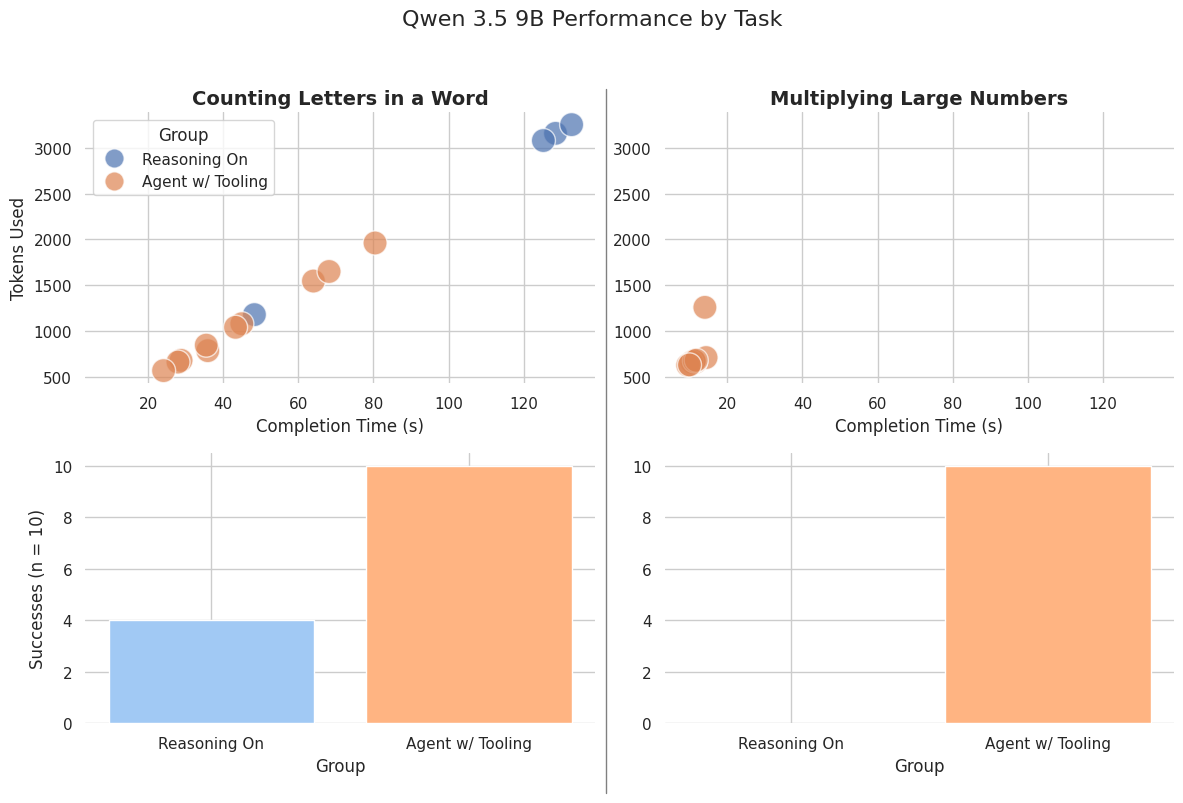

In [ ]:
# @title Generate plots of results

# copy of df only including successful trials
plot_data = df.copy()
plot_data = plot_data[plot_data["success"] == 1]
labels = ["Reasoning On", "Agent w/ Tooling"]

sns.set_theme(style="whitegrid")

f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
ax1.sharex(ax2)
ax1.sharey(ax2)
ax3.sharex(ax4)
ax3.sharey(ax4)

sns.despine(f, left=True, bottom=True)

group_order = plot_data["group"].unique()

# scatterplots
for ax, category in zip((ax1, ax2), plot_data["category"].unique()):
    sns.scatterplot(
        x="time", y="token_count",
        hue="group", s=300, hue_order=group_order,
        linewidth=1, alpha=0.7,
        data=plot_data[plot_data["category"] == category],
        ax=ax
    )

ax1.set_title("Counting Letters in a Word", fontsize=14, fontweight="bold")
ax2.set_title("Multiplying Large Numbers", fontsize=14, fontweight="bold")
ax1.set(xlabel="Completion Time (s)", ylabel="Tokens Used")
ax2.set(xlabel="Completion Time (s)", ylabel="")

# settings for scatterplot legend
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, title="Group", markerscale=0.8)
ax2.legend().remove()

# barplots
for ax, category in zip(
    (ax3, ax4),
    plot_data["category"].unique(),
):
    subset = plot_data[plot_data["category"] == category]
    success_counts = subset.groupby("group")["success"].sum().reindex(group_order)
    ax.bar(group_order, success_counts, color=sns.color_palette("pastel"))
    #ax.set_title(title)
    ax.set_xlabel("Group")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)

ax3.set_ylabel("Successes (n = 10)")



line = Line2D([0.512, 0.512], [0, 0.88], transform=f.transFigure, color="gray", linewidth=1)
f.add_artist(line)

f.suptitle("Qwen 3.5 9B Performance by Task", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

This figure gives us a more detailed look at the results. We can see that one of the successful `reasoning_on` trials beat the agent in both time and tokens for the letter counting task. Overall though, it's still clear that the agent performed consistently better for both experiment categories. We can also see the linear relationship between completion time and token usage more clearly in the scatterplots.

---

## Final Thoughts

We've now seen how agentic tooling can **drastically increase the response accuracy** for the LLMs that power AI chatbots. Although a user could choose a existing deterministic means to solve a problem (software or otherwise), users tend to prefer the simplicity of natural language. There's also something to be said about the convenience of using a single unified interface to solve most problems.

There still exists a hurdle in implementing this kind of tooling for a large range of tasks: the labor required to create a number of appropriate tools. One common solution involves teaching a model to use an interactive shell/environment like Bash or Python REPL. This solution seems apt, given that LLMs are quite capable at programming tasks. Another solution I've considered is using tooling that integrates with existing web-based tools, such as [Wolfram Alpha](https://www.wolframalpha.com/).

### Wolfram Alpha

Wolfram Alpha a computational knowledge engine that's designed to solve a variety of math and science problems using natural language. It does carry limitations, in that a user needs to clearly specify the parameters of their problem in order to get a viable solution. A agent-based chatbot could extend the functionality of Wolfram Alpha by leveraging its own capabilities. For example, if the user needs to solve a real-world problem and isn't sure how to structure it mathematically, the model could reframe the user's query to include specific parameters that Wolfram Alpha could then solve.

One caveat here would be that any system integrating Wolfram Alpha would **consistently require an internet connection**, whereas tooling that operates locally would be available to users regardless of internet access. This may not be a problem for most users today, since internet access is widely available, and most chatbots are accessed directly from the web.

### "Respond with the answer only."

You may have noticed that I've added this phrase at the end of prompts for each experiment. The main reason I've done this is because Qwen would occasionally perform it's own reasoning steps within the response, even when reasoning mode was turned off. Another reason was that the model's responses would slightly vary in structure, so this makes it much easier to verify the model's response.

There's a reasonable argument that appending a phrase like this could affect the model's response, and I believe that's a valid assumption. I have noticed that Qwen's responses were better when it generated small reasoning steps within it's response. It also wouldn't surprise me to learn that the model performs better when it answers in a full sentence. If you truly wanted to control for this, you could probably use regular expressions to effectively parse the model's answer in the vast majority of cases.